---
format:
  html:
    code-fold: true
    code-summary: "Mostrar código"
---

# Práctica 2. Análisis de los rendimientos en fabricación de queso mediante `Python`

---

***Documento en elaboración***

---

En esta práctica utilizaremos un conjunto de datos que provienen de una fábrica de queso tipo ibérico. Con los valores analíticos calcularemos los rendimientos queseros utilizando Python, y nos apoyaremos en diferentes tipos de gráficos para explicar los resultados que hemos obtenido. Utilizaremos los datos calculados aquí para hacer un balance de materia y calcular las pérdidas de nuestra fabricación. 

Para ayudar a concentrarse en los resultados, el código *python* se presenta plegado, de manera que no interfiera demasiado en la presentación. Puede desplegarse para ver cómo se han generado cada tabla y cada gráfico.

Como siempre, es opcional descargar los datos de ejemplo y abrir el cuaderno en Colab para ejecutar el código a medida que se avanza ne el estudio.

[Abrir este cuaderno en Google Colab/](https://colab.research.google.com/github/juanriera/master-queseria/blob/master/090-pract02-rendimientos.ipynb)

[Descargar los datos de ejemplo utilizados en este cuaderno (archivo `fab_queso_bm_limpio.csv`)](https://raw.githubusercontent.com/juanriera/master-queseria/master/datos/fab_queso_bm_limpio.csv)

Empezamos el análisis inicializando las bibliotecas de `Python`, cargamos los datos del `CSV`, creamos el índice de fecha y mostramos los primeros registros del dataframe para comprobar que todo es correcto.

---

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

url_datos = 'https://raw.githubusercontent.com/juanriera/master-queseria/master/datos/fab_queso_bm_limpio.csv'

try:
    df = pd.read_csv(url_datos, decimal = ",", sep=';', encoding='ISO-8859-1')
except Exception as e:
    print(f"Error al cargar el archivo: {e}")

# crear index con fecha
df['fecha_index'] = pd.to_datetime(
    df['fecha'], 
    format='%d/%m/%Y',  # Formato Día/Mes/Año confirmado
    errors='coerce'     # Clave: convierte los valores que no puede leer a NaT (Not a Time)
)
# 2. Limpiar NaT y establecer el índice
df.dropna(subset=['fecha_index'], inplace=True)
df.set_index('fecha_index', inplace=True)
df.sort_index(inplace=True)

df.head()

,fecha,receta,litros_past,kg_cuba,est_cuba,mg_cuba,mp_cuba,lactosa_cuba,ph_final_moldeo_cuba,formato,est_salida_salmuera,mg_salida_salmuera,ph_salida_salmuera,peso_queso_total,sal_queso
fecha_index,,,,,,,,,,,,,,,
2022-02-23,23/02/2022,light,12330,12860.510,10.28,2.46,3.38,4.44,6.46,3 kg,50.85,20.34,5.44,1419.3,1.47
2022-02-24,24/02/2022,mezcla,7500,7704.462,12.80,4.90,3.89,4.01,6.35,barra,59.42,32.13,5.40,1062.4,1.31
2022-03-01,01/03/2022,light,13030,13867.370,10.41,2.47,3.43,4.51,6.40,barra,52.10,21.15,5.34,1536.0,1.17
2022-03-01,01/03/2022,vaca,14820,15810.990,12.85,5.03,3.97,3.85,6.38,barra,55.94,30.50,5.41,2351.0,1.55
2022-03-04,04/03/2022,oveja,11890,12344.190,14.37,5.86,4.55,3.96,6.42,barra,57.60,31.99,5.42,2051.0,NaN


En total, tenemos 45 entradas que corresponden a fabricaciones diarias, desde el 23/02/2022 hasta el 30/5/2022. 

El fichero de datos incluye diferentes datos analíticos:

| Columna | Descripción |
|--------|----------------|
| **fecha**  | día de fabricación |
| **receta** | tipo de queso fabricado |
| **litros_past** | litros de leche enviados a pasteurización|
| **kg_cuba** | cantidad de leche recibida en cuba, en kilos |
| **est_cuba** | extracto seco de la leche en la cuba|
| **mg_cuba** | materia grasa de la leche en la cuba|
| **mp_cuba** | materia proteica de la leche en la cuba |
| **lactosa_cuba** | lactosa de la leche en la cuba |
| **ph_final_moldeo_cuba** | pH del queso al final del proceso de moldeo|
| **formato** | formato de moldeo |
| **est_salida_salmuera** | extracto seco total del queso después del salado |
| **mg_salida_salmuera** | materia grasa del queso después del salado |
| **ph_salida_salmuera** | pH del queso después del salado|
| **peso_queso_total** | peso del queso después del salado |
| **sal_queso** | porcentaje de sal analizada en el queso|

El queso se fabrica en varias recetas, y se envasa en diferentes formatos:

| Receta | Formatos |
|--------|----------|
| i+D | 3 kg, 500 g, barra |
| light | 3 kg, 500 g, barra |
| mezcla | 3 kg, 500 g, barra |
| oveja | barra |
| vaca | barra |

El fichero de datos también contiene varios ensayos del departamento de i+D que se han mantenido para mostrar que a veces las cosas no salen bien a la primera...

In [17]:
#| include: false
#| echo: false
#| eval: false

# este código simplemente formatea algunos datos en markdown para preparar el documento 
# y no se usa en el análisis
def info_as_markdown(df):
    summary = pd.DataFrame({
        "Column": df.columns,
        "Non-Null Count": df.count(),
        "Null Count": df.isnull().sum(),
        "Dtype": df.dtypes.astype(str)
    }).reset_index(drop=True)

    markdown = "| Column | Non-Null Count | Null Count | Dtype |\n"
    markdown += "|--------|----------------|------------|-------|\n"
    for _, row in summary.iterrows():
        markdown += f"| {row['Column']} | {row['Non-Null Count']} | {row['Null Count']} | {row['Dtype']} |\n"
    return markdown

# print(info_as_markdown(df))

def tabla_agrupada_markdown(df):
    agrupado = df.groupby('receta')['formato'].apply(lambda x: ', '.join(sorted(set(x)))).reset_index()
    markdown = "| Receta | Formatos |\n"
    markdown += "|--------|----------|\n"
    for _, row in agrupado.iterrows():
        markdown += f"| {row['receta']} | {row['formato']} |\n"
    return markdown

# print(tabla_agrupada_markdown(df))

## Presentación de algunos gráficos básicos

Vamos a explorar los datos antes de empezar el análisis, y los usaremos para visualizar las diferencias de rendimiento entre mezclas.

Podemos calcular el rendimiento simple como los kilos de queso que podemos obtener con 100 L de leche

In [18]:
#| code-fold: false

df['rendimiento_simple'] = df['peso_queso_total']/df['litros_past']*100

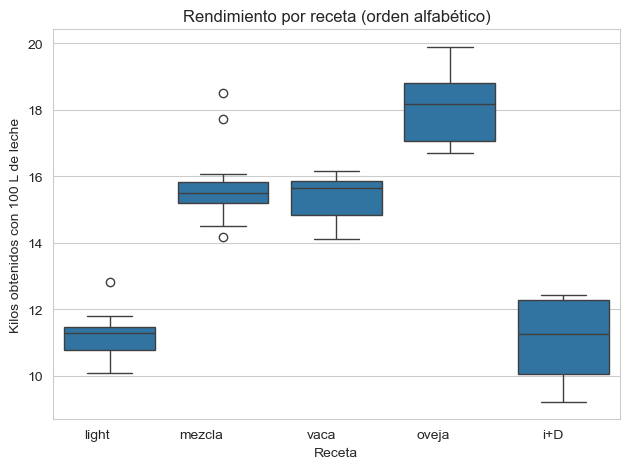

In [19]:

sns.boxplot(data=df, x='receta', y='rendimiento_simple')
plt.xticks(rotation=0, ha='right')
plt.title('Rendimiento por receta (orden alfabético)')
plt.xlabel('Receta')
plt.ylabel('Kilos obtenidos con 100 L de leche')
plt.tight_layout()
plt.show()


Aunque es más frecuente calcular el rendimiento simple como los litros de leche que necesitamos para hacer un kilo de queso

In [20]:
#| code-fold: false

df['rendimiento_simple'] = df['litros_past']/df['peso_queso_total']

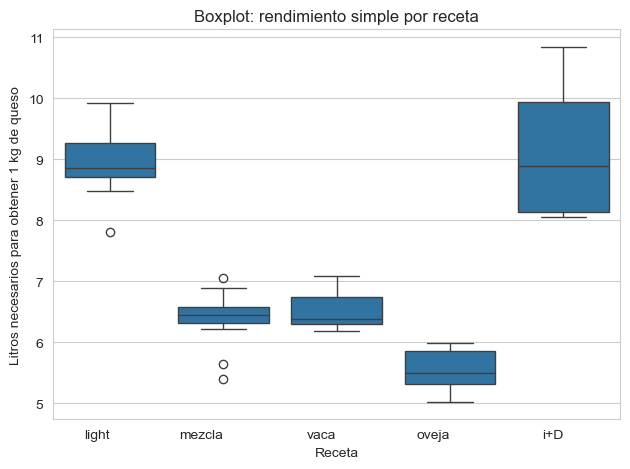

In [21]:
sns.boxplot(data=df, x='receta', y='rendimiento_simple')
plt.xticks(rotation=0, ha='right')
plt.title('Boxplot: rendimiento simple por receta')
plt.xlabel('Receta')
plt.ylabel('Litros necesarios para obtener 1 kg de queso')
plt.tight_layout()
plt.show()

El *boxplot* es muy útil para resumir grandes cantidades de información, pero cuando el número de puntos es muy bajo, puede resultarnos más útil la visualización mediante otro tipo de gráficos que nos muestren los puntos individuales agrupados. Entre estas visualizaciones, la biblioteca `seaborn` nos ofrece el gráfico llamado *beeswarm* mediante la función `swarmplot()`, y también el *dotplot*, mediante la función `stripplot()`.

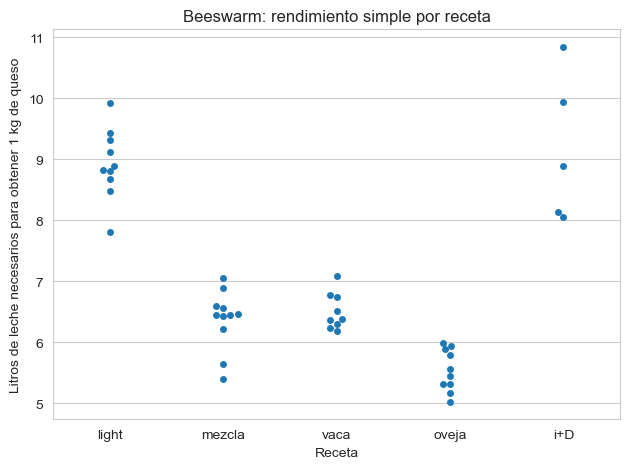

In [22]:
sns.swarmplot(data=df, x='receta', y='rendimiento_simple', size=5)
plt.xticks(rotation=0) # es opcional rotar lo rótulos para mejorar la visibilidad cuando los titulos son largos y se solapan
plt.title('Beeswarm: rendimiento simple por receta')
plt.xlabel('Receta')
plt.ylabel('Litros de leche necesarios para obtener 1 kg de queso')
plt.tight_layout()
plt.show()

El *stripplot* muestra los puntos en distribución vertical sobre las categorías; para evitar que los puntos con las mismas coordenada se solapen, utilizamos la opción *jitter*, que introduce un pequeño *ruido* aleatorio para desplazar las coordenadas de los puntos evitando su solapamiento.

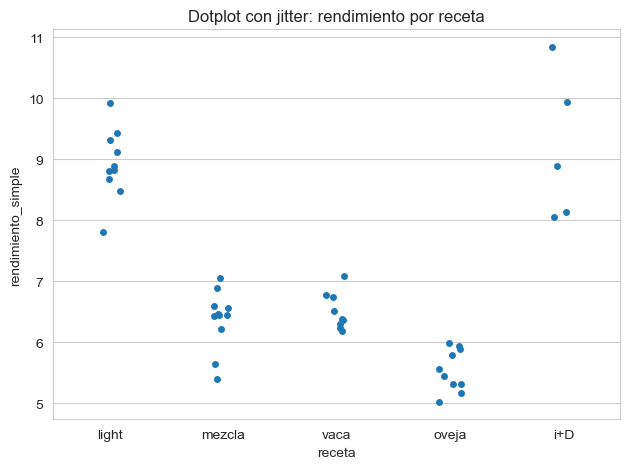

In [23]:
sns.stripplot(data=df, x='receta', y='rendimiento_simple', jitter=True, size=5)
plt.xticks(rotation=0)
plt.title('Dotplot con jitter: rendimiento por receta')
plt.tight_layout()
plt.show()

Este diagrama puede superponerse al *boxplot*, lo que nos permite completar la visualización de los puntos y la interpretación que hace el *boxplot* de su distribución.

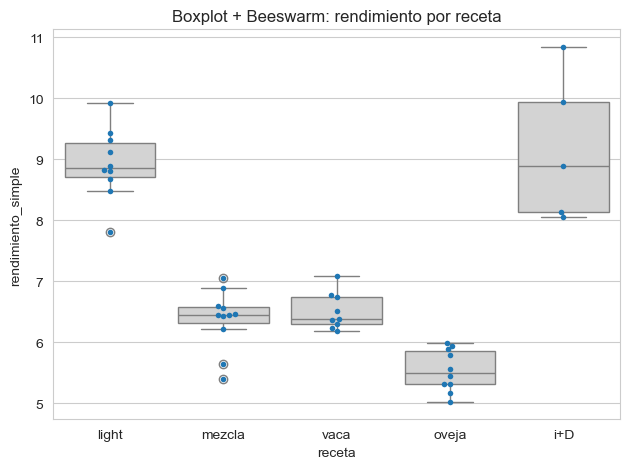

In [24]:
sns.boxplot(data=df, x='receta', y='rendimiento_simple', color='lightgray')
sns.swarmplot(data=df, x='receta', y='rendimiento_simple', size=4)
plt.xticks(rotation=0)
plt.title('Boxplot + Beeswarm: rendimiento por receta')
plt.tight_layout()
plt.show()

## Análisis previo de los datos

Utilizando el *beeswarm*, hemos visto las de *rendimiento simple* entre las diferentes recetas. Veamos también si el formato en el que ha sido moldeado el queso puede haber influido en los valores de rendimiento obtenidos, para todos los productos, ¿quizás por pérdidas de producto en el moldeo?

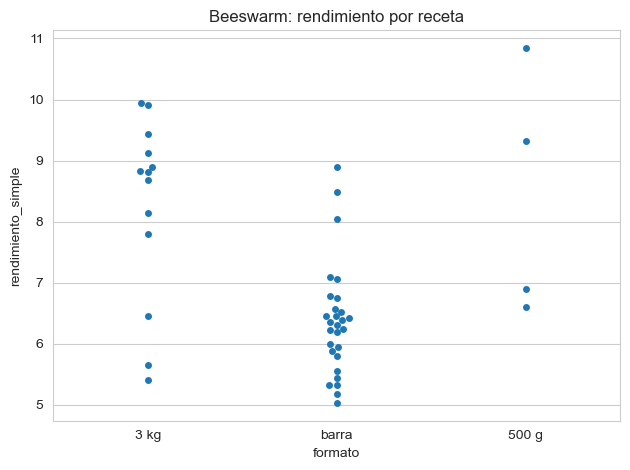

In [25]:
sns.swarmplot(data=df, x='formato', y='rendimiento_simple', size=5)
plt.xticks(rotation=0)
plt.title('Beeswarm: rendimiento por receta')
plt.tight_layout()
plt.show()

A la vista de la gráfica, parece que el moldeo en barra nos hace empeorar el rendimiento. Pero si miramos con más detalle, vemos que no es así. Si introducimos un código de color para cada receta, vemos que los rendimientos de las diferentes recetas son *aproximadamente* los mismos con independencia del formato.

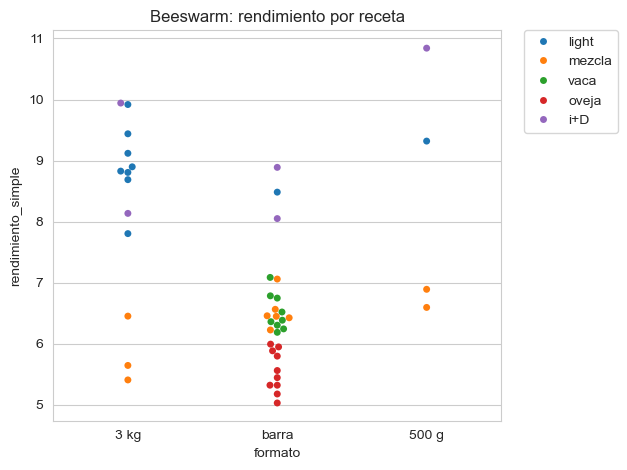

In [26]:
sns.swarmplot(data=df, x='formato', y='rendimiento_simple', hue='receta', size=5)
plt.xticks(rotation=0)
plt.title('Beeswarm: rendimiento por receta')

# Mover la leyenda fuera del gráfico
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

Esto nos ayuda a comprender que no debemos sacar conclusiones apresuradas antes de haber completado el análisis detallado de la información disponible. En realidad, si vemos los valores de rendimiento por receta (colores), en cada tipo de queso el rendimiento es muy semejante, con independencia del formato.

Como estamos evaluando el rendimiento como los litros necesarios para obtener 1 kg de queso, resulta que la cantidad de agua que tenga el queso nos influye en el cálculo: cuanto más húmedo el queso, más favorable será el valor el rendimiento simple. Fijémonos en el queso de mezcla: hay un valor de rendimiento muy favorable, de poco más de 5 L/kg de queso, pero vemos que el queso ha tenido casi un 52% de humedad. En cambio, otra fabricación de esa misma receta, que sólo tiene algo más de 40% de humedad, ha necesitado 7 L/kg. 

Así, dentro de cada receta, los mejores rendimientos en L/kg aparecen siempre en quesos más húmedos, y los peores, en quesos más secos. Veámoslo creando una columna adicional para los valores d humedad.

In [27]:
#| code-fold: false

# Crear columna de humedad
df['humedad_salida_salmuera'] = 100 - df['est_salida_salmuera']

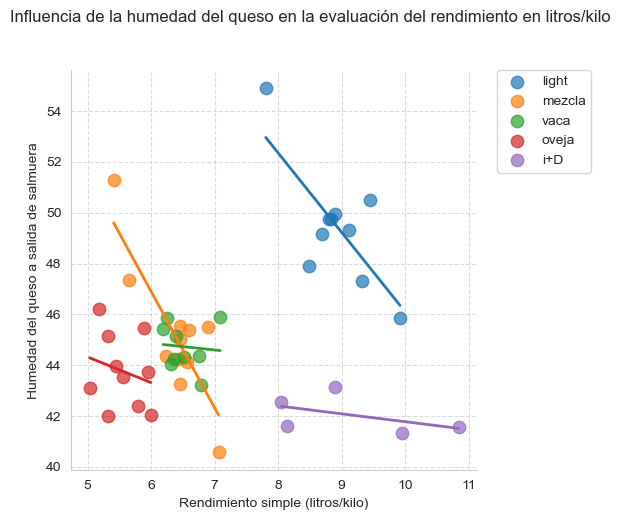

In [ ]:
# crear dataframe para seaborn sin index para evitar errores
df_plot_sns = df.reset_index(drop=True)

# Crear gráfico con regresión lineal por receta
g = sns.lmplot(
    data=df_plot_sns,
    x='rendimiento_simple',
    y='humedad_salida_salmuera',
    hue='receta',
    ci=None,
    scatter_kws={'s': 80, 'alpha': 0.7},
    line_kws={'linewidth': 2}
)

# Eliminar la leyenda generada por FacetGrid
g._legend.remove()

# Personalizar título y ejes
g.fig.suptitle('Influencia de la humedad del queso en la evaluación del rendimiento en litros/kilo', y=1.03)
g.set_axis_labels('Rendimiento simple (litros/kilo)', 'Humedad del queso a salida de salmuera')
g.ax.grid(True, linestyle='--', alpha=0.7)

# Mover la leyenda fuera del gráfico
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()



Por esta razón, debemos calcular el rendimiento mediante parámetros que no se vean afectados por la humedad del queso, sino que reflejen con precisión la calidad del trabajo quesero. La mejor forma de hacerlo consiste en calcular el porcentaje de materia quesera que hemos sido capaces de retener en el queso. Dado que los elementos de valor de la leche, que son los que se utilizan en el pago por calidad, son la materia grasa y la proteína, calcularemos la recuperación de materia grasa, de materia proteica y de extracto seco magro. 

Estos valores son propios de cada tecnología quesera, y cada uno sirve de referencia para comprender cuáles son los diferentes problemas en fabricación, 

* Una mala retención de materia grasa
* Una mala retención de proteína
* Una mala retención de extracto seco magro

Dado que nuestros valores analíticos están expresados en porcentaje en peso, calculamos las cantidades de materia como se indica a continuación:

In [29]:
#| code-fold: false

### 1. Cálculos de Entrada
df['est_kg_cuba'] = df['kg_cuba'] * df['est_cuba'] / 100
df['mg_kg_cuba'] = df['kg_cuba'] * df['mg_cuba'] / 100
df['mp_kg_cuba'] = df['kg_cuba'] * df['mp_cuba'] / 100
df['esm_kg_cuba'] = df['est_kg_cuba'] - df['mg_kg_cuba'] 

### 2. Cálculos de Salida
df['est_kg_queso'] = df['peso_queso_total'] * df['est_salida_salmuera'] / 100
df['mg_kg_queso'] = df['peso_queso_total'] * df['mg_salida_salmuera'] / 100
df['esm_kg_queso'] = df['est_kg_queso'] - df['mg_kg_queso']
df['sal_kg_queso'] = df['peso_queso_total'] * df['sal_queso']/100

### 3. Coeficientes de recuperación (expresado en porcentaje)
df['coef_recup_mg']  = df['mg_kg_queso']/df['mg_kg_cuba'] * 100
df['coef_recup_mp']  = df['esm_kg_queso']/df['mp_kg_cuba'] * 100 # atencion a la fórmula de cálculo, deberia ser mp_kg_queso
df['coef_recup_esm'] = df['esm_kg_queso']/df['esm_kg_cuba'] * 100

### 4. Consumos de materia por kilo de queso (expresado en gramos de materia por kilo de queso)
df['consumo_mg_kg'] = df['mg_kg_cuba'] / df['peso_queso_total'] * 1000
df['consumo_mp_kg'] = df['mp_kg_cuba'] / df['peso_queso_total'] * 1000

Comparemos ahora la recuperación de materia medida por estos coeficientes entre recetas.

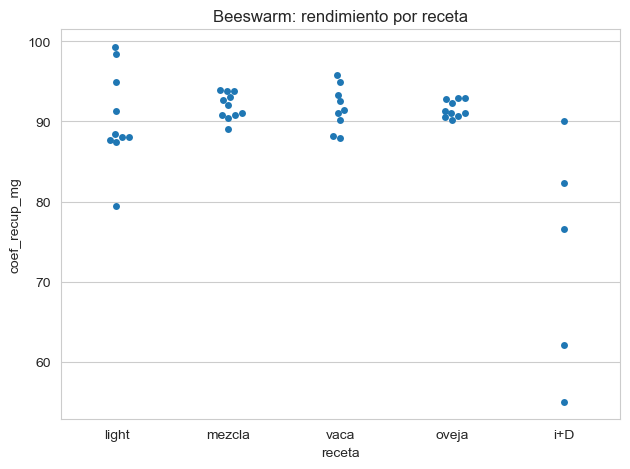

In [31]:
# crear dataframe para seaborn sin index para evitar errores
df_sns = df.reset_index(drop=True)

sns.swarmplot(data=df_sns, x='receta', y='coef_recup_mg', size=5)
plt.xticks(rotation=0)
plt.title('Beeswarm: rendimiento por receta')
plt.tight_layout()
plt.show()

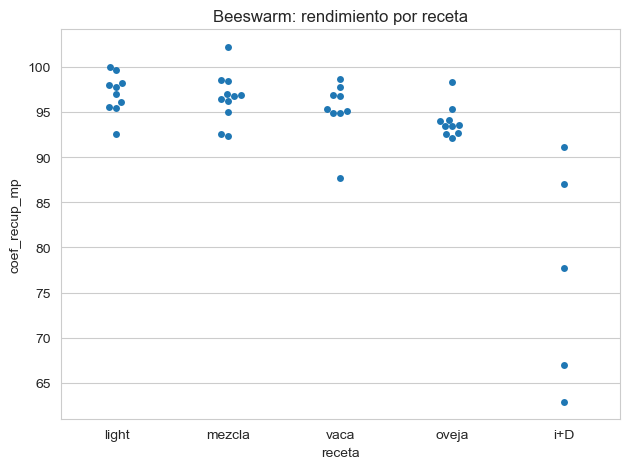

In [32]:
sns.swarmplot(data=df_sns, x='receta', y='coef_recup_mp', size=5)
plt.xticks(rotation=0)
plt.title('Beeswarm: rendimiento por receta')
plt.tight_layout()
plt.show()

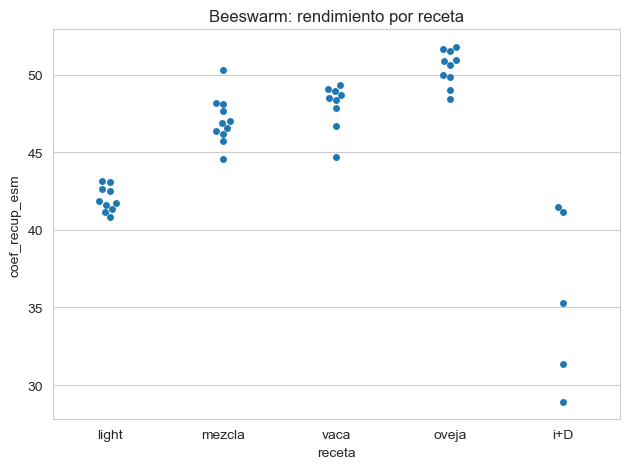

In [33]:
sns.swarmplot(data=df_sns, x='receta', y='coef_recup_esm', size=5)
plt.xticks(rotation=0)
plt.title('Beeswarm: rendimiento por receta')
plt.tight_layout()
plt.show()

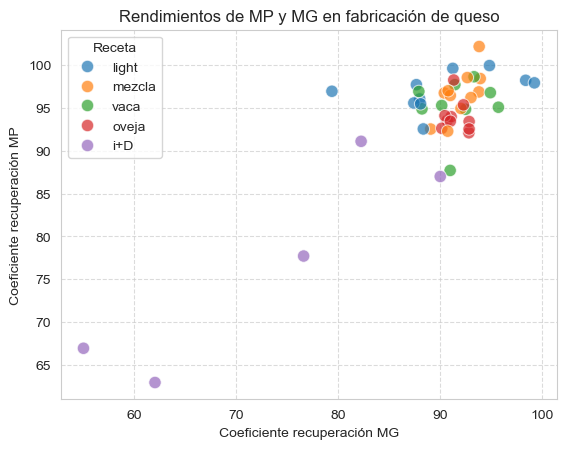

In [34]:
sns.scatterplot(data=df_sns, x='coef_recup_mg', y='coef_recup_mp', hue='receta', s=80, alpha=0.7)
plt.title('Rendimientos de MP y MG en fabricación de queso')
plt.xlabel('Coeficiente recuperación MG')
plt.ylabel('Coeficiente recuperación MP')
plt.legend(title='Receta') # Mostrar leyenda para la especie
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Filtremos los resultados de i+D que no son relevantes para nuestro análisis y están distorionando la escala del gráfico.

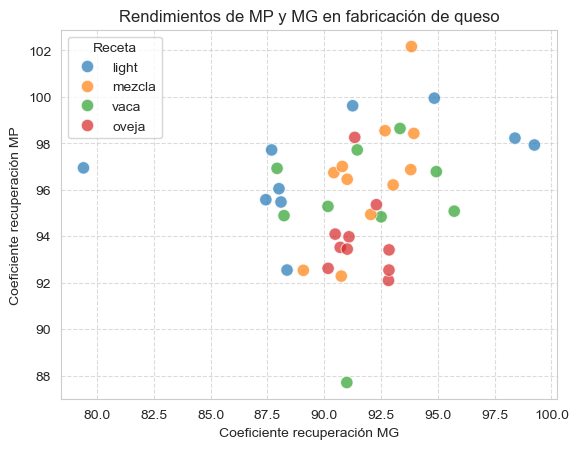

In [35]:
sns.scatterplot(data=df[df['receta'] != 'i+D'], 
                x='coef_recup_mg', 
                y='coef_recup_mp', 
                hue='receta', 
                s=80, 
                alpha=0.7)
plt.title('Rendimientos de MP y MG en fabricación de queso')
plt.xlabel('Coeficiente recuperación MG')
plt.ylabel('Coeficiente recuperación MP')
plt.legend(title='Receta') # Mostrar leyenda para la especie
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Calculemos los centroides de cada grupo (receta) mediante la mediana.

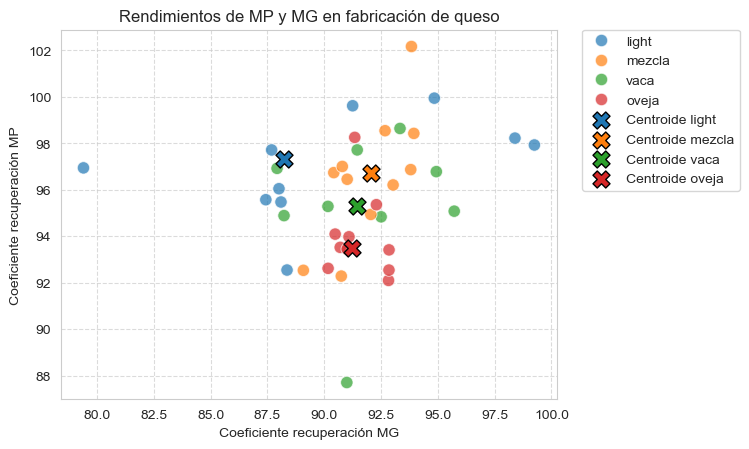

In [36]:

# Filtrar receta 'i+D'
df_filtrado = df[df['receta'] != 'i+D'].reset_index(drop=True)

# Crear paleta de colores por receta
recetas = df_filtrado['receta'].unique()
palette = sns.color_palette('tab10', n_colors=len(recetas))
color_dict = dict(zip(recetas, palette))

sns.scatterplot(data=df[df['receta'] != 'i+D'], 
                x='coef_recup_mg', 
                y='coef_recup_mp', 
                hue='receta', 
                palette = color_dict,
                s=80, 
                # edgecolor = 'black',
                alpha=0.7)

# Calcular y dibujar centroides
centroides = df.groupby('receta')[['coef_recup_mg', 'coef_recup_mp']].median()

for receta in recetas:
    centro = centroides.loc[receta]
    plt.scatter(
        centro['coef_recup_mg'],
        centro['coef_recup_mp'],
        color=color_dict[receta],
        marker='X',
        s=150,
        edgecolor='black',
        label=f'Centroide {receta}'
    )

plt.title('Rendimientos de MP y MG en fabricación de queso')
plt.xlabel('Coeficiente recuperación MG')
plt.ylabel('Coeficiente recuperación MP')
plt.legend(title='Receta') # Mostrar leyenda para la especie
# Mover la leyenda fuera del gráfico
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


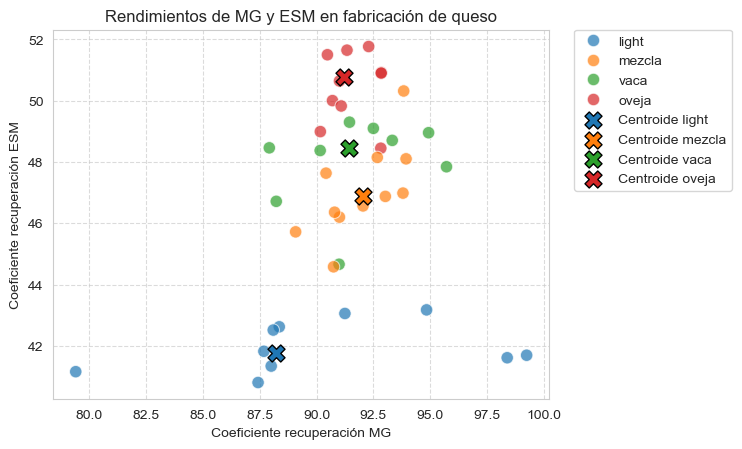

In [37]:
sns.scatterplot(data=df[df['receta'] != 'i+D'], 
                x='coef_recup_mg', 
                y='coef_recup_esm', 
                hue='receta', 
                palette = color_dict,
                s=80, 
                # edgecolor = 'black',
                alpha=0.7)

# Calcular y dibujar centroides
centroides = df.groupby('receta')[['coef_recup_mg', 'coef_recup_esm']].median()

for receta in recetas:
    centro = centroides.loc[receta]
    plt.scatter(
        centro['coef_recup_mg'],
        centro['coef_recup_esm'],
        color=color_dict[receta],
        marker='X',
        s=150,
        edgecolor='black',
        label=f'Centroide {receta}'
    )

plt.title('Rendimientos de MG y ESM en fabricación de queso')
plt.xlabel('Coeficiente recuperación MG')
plt.ylabel('Coeficiente recuperación ESM')
plt.legend(title='Receta') # Mostrar leyenda para la especie
# Mover la leyenda fuera del gráfico
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Finalmente, aprovechamos nuestros cálculos para crear un documento con los rendimientos y el balance de materia de la fabricación, que exportaremos a un 'csv' y que podemos analizar sea en *python* o en Excel mediante tablas dinámicas.

In [38]:

### 5. Balance de Materia (Salida - Entrada)
# La falta de producto queda como negativo al hacer Salida - Entrada
df['balance_est'] = df['est_kg_queso'] - df['est_kg_cuba']
df['balance_mg'] = df['mg_kg_queso'] - df['mg_kg_cuba']
df['balance_esm'] = df['esm_kg_queso'] - df['esm_kg_cuba'] - df['sal_kg_queso']

### 6. Preparación y Exportación del DataFrame de Resultados
# Columnas finales a incluir en el reporte
columnas_balance = [
    'fecha', 'receta', 'formato',
    'litros_past', 'peso_queso_total',
    'est_kg_cuba', 'est_kg_queso', 
    'mg_kg_cuba', 'mg_kg_queso', 
    'mp_kg_cuba',
    'esm_kg_cuba', 'esm_kg_queso', 
    'balance_est', 'balance_mg', 'balance_esm',
    'coef_recup_mg', 'coef_recup_mp', 'coef_recup_esm',
    'consumo_mg_kg', 'consumo_mp_kg'
]

# Crear un nuevo DataFrame con las columnas de interés
df_balance = df[columnas_balance].copy()

# Guardar el DataFrame con punto decimal y separador ';'
nombre_archivo_salida = 'datos/informe_balance_materia.csv'

df_balance.to_csv(
    nombre_archivo_salida, 
    sep=';', 
    index=False,
    decimal=','
)


Ahora vamos a crear un nuevo `csv`con el balance de materia semanal, aprovechando las funciones de `pandas`para crear una columna de semana ISO.

In [39]:
# 1. Crear la columna 'semana' usando el formato ISO (Lunes=Día 1)
# Usamos el índice del DataFrame (que debe ser DatetimeIndex)
df['semana_iso'] = df.index.strftime('%G-W%V') 

print("✅ Columna 'semana_iso' creada con el estándar Lunes-Domingo.")

✅ Columna 'semana_iso' creada con el estándar Lunes-Domingo.


In [47]:
# Columnas que queremos sumarizar (Balances + Entradas + Salidas)
columnas_a_sumarizar = [
    # Entradas
    'est_kg_cuba', 'mg_kg_cuba', 'esm_kg_cuba',
    # Salidas
    'est_kg_queso', 'mg_kg_queso', 'esm_kg_queso',
    # Balances
    'balance_est', 'balance_mg', 'balance_esm'
]

# 2. Agrupar por 'semana_iso' y 'receta' y calcular la SUMA de todas las columnas
df_balance_semanal_completo = df.groupby(['semana_iso', 'balance_mg'])[columnas_a_sumarizar].sum()

# Renombrar las columnas para indicar que son totales
df_balance_semanal_completo.columns = [f'total_{col}' for col in columnas_a_sumarizar]

In [48]:
# 1. Definir el nombre del archivo de salida
nombre_archivo_final = 'datos/reporte_balance_completo_semanal_iso.csv'

# 2. Exportar el DataFrame a CSV
df_balance_semanal_completo.to_csv(
    nombre_archivo_final, 
    sep=';',        # Usa punto y coma como separador de columnas
    index=True,     # Mantiene las columnas de agrupación ('semana_iso' y 'receta')
    decimal=','     # Usa coma como separador decimal
)

In [57]:
df_sns  = df_balance_semanal_completo.reset_index(drop=False) # False mantiene la columna index como columna normal

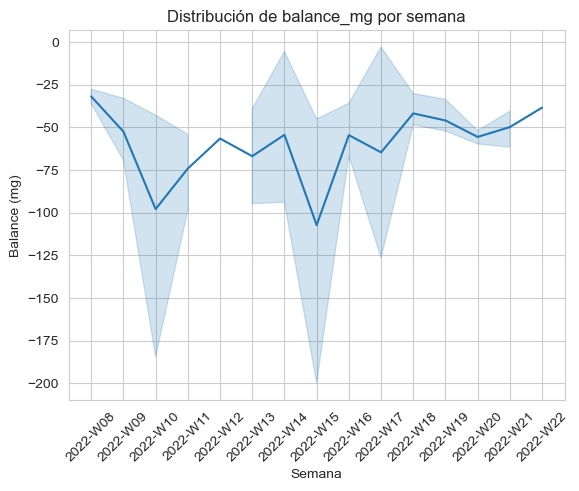

In [ ]:
sns.lineplot(x='semana_iso', y='balance_mg', data=df_sns)

# Opcional: mejorar la visualización
plt.title('Distribución de balance_mg por semana')
plt.xlabel('Semana')
plt.ylabel('Balance (mg)')
plt.xticks(rotation=45)  # Si los nombres de semana son largos
plt.show()

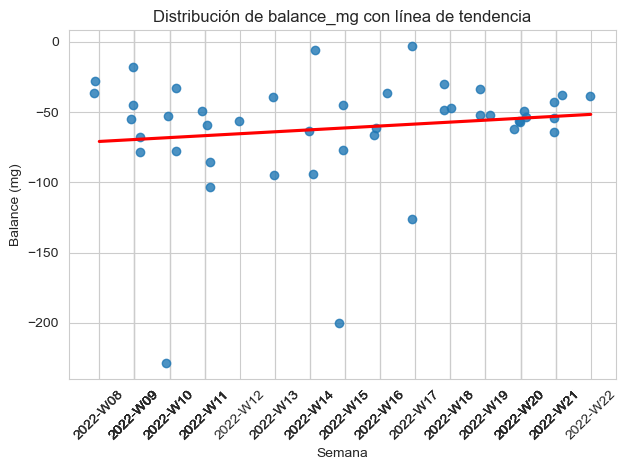

In [65]:

# Convertir semana_iso a números temporales
df_sns['semana_num'] = pd.factorize(df_sns['semana_iso'])[0]

# Dibujar la línea de tendencia con regplot
sns.regplot(
    x='semana_num',
    y='balance_mg',
    data=df_sns,
    scatter=True,
    x_jitter=0.2,     # añade jitter horizontal
    y_jitter=0.2,     # añade jitter vertical
    ci=None,
    line_kws={'color': 'red'},
)

# Reemplazar los ticks del eje X con las etiquetas originales
plt.xticks(
    ticks=df_sns['semana_num'],
    labels=df_sns['semana_iso'],
    rotation=45
)

# Mejorar visualización
plt.title('Distribución de balance_mg con línea de tendencia')
plt.xlabel('Semana')
plt.ylabel('Balance (mg)')
plt.tight_layout()
plt.show()


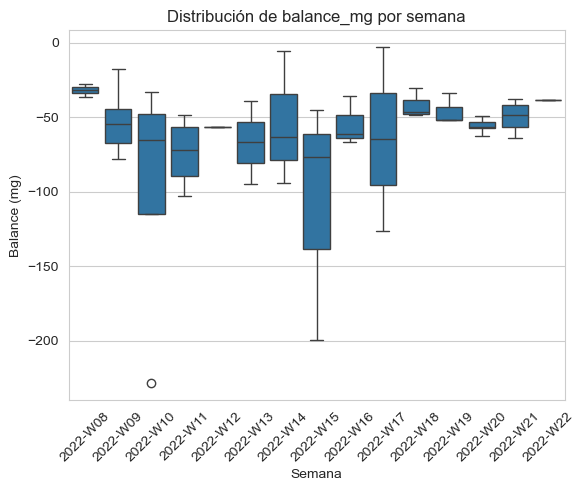

In [56]:
# Crear el boxplot
sns.boxplot(x='semana_iso', y='balance_mg', data=df_sns)

# Opcional: mejorar la visualización
plt.title('Distribución de balance_mg por semana')
plt.xlabel('Semana')
plt.ylabel('Balance (mg)')
plt.xticks(rotation=45)  # Si los nombres de semana son largos

plt.show()
